In [365]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mlt
from matplotlib import pyplot as plt

# Data Importing and Pre-Processing
Here I will be importing CPI data, USDZAR exchange rates, money supply (M3), and prime rates


## CPI

In [366]:
#Importing CPI data I downloaded from SARB website
cpi_df = pd.read_csv('TSReport-2026-6-6-21-49-46.csv', parse_dates=[0],header=0)

C:\Users\tebog\AppData\Local\Temp\ipykernel_19132\861616439.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  cpi_df = pd.read_csv('TSReport-2026-6-6-21-49-46.csv', parse_dates=[0],header=0)


In [367]:
cpi_df

,Date,Code,Description,Unit of Measure,Value
2010-01-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,5.9
2010-02-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,5.4
2010-03-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,4.9
2010-04-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,4.6
2010-05-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,4.1
...,...,...,...,...,...
2025-10-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,3.1
2025-11-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,3.2
2025-12-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,3.3
2026-01-01,KBP7177A,Consumer prices: CPI excluding food and non-al...,fuel and electricity (All urban areas),Percentage,3.4


In [368]:
cpi_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 194 entries, 2010-01-01 to 2026-02-01
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             194 non-null    object 
 1   Code             194 non-null    object 
 2   Description      194 non-null    object 
 3   Unit of Measure  194 non-null    object 
 4   Value            194 non-null    float64
dtypes: float64(1), object(4)
memory usage: 9.1+ KB


In [369]:
#Removing columns that will not be usefull
cpi_df = cpi_df.drop(columns=['Code', 'Description', 'Unit of Measure'],axis=1)

In [370]:
cpi_df

,Date,Value
2010-01-01,KBP7177A,5.9
2010-02-01,KBP7177A,5.4
2010-03-01,KBP7177A,4.9
2010-04-01,KBP7177A,4.6
2010-05-01,KBP7177A,4.1
...,...,...
2025-10-01,KBP7177A,3.1
2025-11-01,KBP7177A,3.2
2025-12-01,KBP7177A,3.3
2026-01-01,KBP7177A,3.4


In [371]:
#Date column has been confused with code column so this will be a quick fix
cpi_df = cpi_df.reset_index()

In [372]:
cpi_df = cpi_df.drop('Date', axis=1)

In [373]:
#Now giving date its correct column name 
cpi_df.rename(mapper = {'index':'Date', 'Value':'CPI'}, axis=1, inplace=True)

In [374]:
cpi_df

,Date,CPI
0,2010-01-01,5.9
1,2010-02-01,5.4
2,2010-03-01,4.9
3,2010-04-01,4.6
4,2010-05-01,4.1
...,...,...
189,2025-10-01,3.1
190,2025-11-01,3.2
191,2025-12-01,3.3
192,2026-01-01,3.4


# USDZAR exchange rates

In [375]:
usdzar_df = pd.read_csv('USD_ZAR Historical Data.csv')

In [376]:
usdzar_df.head()

,Date,Price,Open,High,Low,Vol.,Change %
0,2025/12/01,16.5680,17.1147,17.1658,16.5341,NaN,-3.19%
1,2025/11/01,17.1146,17.3093,17.5814,16.9465,NaN,-1.24%
2,2025/10/01,17.3293,17.2678,17.5140,17.0617,NaN,0.36%
3,2025/09/01,17.2668,17.6758,17.8246,17.2106,NaN,-2.20%
4,2025/08/01,17.6557,18.2144,18.3681,17.4147,NaN,-3.07%


In [377]:
#Only date and price are needed
usdzar_df = usdzar_df.drop(['Open','High', 'Low', 'Vol.', 'Change %'], axis=1)

In [378]:
#Sorting the values by starting date
usdzar_df = usdzar_df.sort_values(by = 'Date')

In [379]:
usdzar_df.head()

,Date,Price
191,2010/01/01,7.6238
190,2010/02/01,7.7170
189,2010/03/01,7.2862
188,2010/04/01,7.3872
187,2010/05/01,7.6749


In [380]:
#Price might confuse me after merging with other dataframes, so USDZAR will work for me 
usdzar_df.rename(mapper={'Price':'USDZAR'}, axis=1, inplace=True)

# Money Supply (M3)

In [381]:
#Importing downloaded data
m3_df = pd.read_csv('M3.csv', parse_dates=[0])

C:\Users\tebog\AppData\Local\Temp\ipykernel_19132\1801963980.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  m3_df = pd.read_csv('M3.csv', parse_dates=[0])


In [382]:
m3_df.head()

,Date,Code,Description,Unit of Measure,Value
0,2010-01-01,KBP1374A,Monetary aggregates / Money supply: M3,Percentage,0.60
1,2010-02-01,KBP1374A,Monetary aggregates / Money supply: M3,Percentage,0.12
2,2010-03-01,KBP1374A,Monetary aggregates / Money supply: M3,Percentage,1.55
3,2010-04-01,KBP1374A,Monetary aggregates / Money supply: M3,Percentage,1.67
4,2010-05-01,KBP1374A,Monetary aggregates / Money supply: M3,Percentage,1.35


Code, Description and Unit of measure will not be usefull, so I will be removing them, then the dataset should be fine

In [383]:
m3_df.drop(['Code', 'Description', 'Unit of Measure'], axis=1, inplace=True)

In [384]:
m3_df

,Date,Value
0,2010-01-01,0.60
1,2010-02-01,0.12
2,2010-03-01,1.55
3,2010-04-01,1.67
4,2010-05-01,1.35
...,...,...
187,2025-08-01,6.18
188,2025-09-01,6.07
189,2025-10-01,7.52
190,2025-11-01,8.26


In [385]:
#Value as column name will be confusing when I merge datasets
m3_df.rename(mapper = {'Value':'M3'}, axis=1, inplace=True)

# Prime Rates 

In [386]:
#Importing downloaded data
prime_df = pd.read_csv('prime rate.csv', parse_dates=[0])

C:\Users\tebog\AppData\Local\Temp\ipykernel_19132\421320010.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  prime_df = pd.read_csv('prime rate.csv', parse_dates=[0])


In [387]:
prime_df.head()

,Indicator,Description
0,Prime lending rate,Benchmark rate at which private banks lend out...
1,Date,Value
2,2026-06-05,10.50
3,2026-06-04,10.50
4,2026-06-03,10.50


In [388]:
#I will be deleting first two rows using their index position, hence Indicator column is set as index
prime_df = pd.read_csv('prime rate.csv', parse_dates=[0], index_col='Indicator')

C:\Users\tebog\AppData\Local\Temp\ipykernel_19132\3610892656.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  prime_df = pd.read_csv('prime rate.csv', parse_dates=[0], index_col='Indicator')


In [389]:
prime_df.head()

,Description
Indicator,
Prime lending rate,Benchmark rate at which private banks lend out...
Date,Value
2026-06-05,10.50
2026-06-04,10.50
2026-06-03,10.50


In [390]:
prime_df.drop(['Prime lending rate', 'Date'], inplace=True)

In [391]:
prime_df.head()

,Description
Indicator,
2026-06-05,10.50
2026-06-04,10.50
2026-06-03,10.50
2026-06-02,10.50
2026-06-01,10.50


In [392]:
#Resetting index so that I can later rename the columns
prime_df = prime_df.reset_index()

In [393]:
prime_df.head()

,Indicator,Description
0,2026-06-05,10.50
1,2026-06-04,10.50
2,2026-06-03,10.50
3,2026-06-02,10.50
4,2026-06-01,10.50


In [394]:
#Renaming columns to their true names
prime_df.rename(mapper={'Indicator':'Date', 'Description':'Prime rate'}, axis=1, inplace=True)

In [395]:
prime_df.head()

,Date,Prime rate
0,2026-06-05,10.50
1,2026-06-04,10.50
2,2026-06-03,10.50
3,2026-06-02,10.50
4,2026-06-01,10.50


In [396]:
#Date is in descending order
prime_df = prime_df.sort_values(by = 'Date')

In [397]:
prime_df.head()

,Date,Prime rate
4513,2010-01-01,10.50
4512,2010-01-02,10.50
4511,2010-01-04,10.50
4510,2010-01-05,10.50
4509,2010-01-06,10.50


# Further Preprocessing
Here I will be making sure frequency of data is the same (monthly) for all variables, and that the start date is 1st Jan 2010 and end date 1st Dec 2025 the for all observations for each variable

In [398]:
#To do that, Date columns need to be converted to datetime format
cpi_df['Date'] = pd.to_datetime(cpi_df['Date'])

In [399]:
cpi_df

,Date,CPI
0,2010-01-01,5.9
1,2010-02-01,5.4
2,2010-03-01,4.9
3,2010-04-01,4.6
4,2010-05-01,4.1
...,...,...
189,2025-10-01,3.1
190,2025-11-01,3.2
191,2025-12-01,3.3
192,2026-01-01,3.4


In [400]:
mask = cpi_df['Date'] <= '2025-12-01'

In [401]:
cpi_df = cpi_df[mask]

In [402]:
#Voilà!
cpi_df

,Date,CPI
0,2010-01-01,5.9
1,2010-02-01,5.4
2,2010-03-01,4.9
3,2010-04-01,4.6
4,2010-05-01,4.1
...,...,...
187,2025-08-01,3.1
188,2025-09-01,3.2
189,2025-10-01,3.1
190,2025-11-01,3.2


In [403]:
usdzar_df.head()

,Date,USDZAR
191,2010/01/01,7.6238
190,2010/02/01,7.7170
189,2010/03/01,7.2862
188,2010/04/01,7.3872
187,2010/05/01,7.6749


In [404]:
#For usdzar the only thing left to do is to make sure date is the same format as other predictors
usdzar_df['Date'] = pd.to_datetime(usdzar_df['Date'])

In [405]:
usdzar_df.head()

,Date,USDZAR
191,2010-01-01,7.6238
190,2010-02-01,7.7170
189,2010-03-01,7.2862
188,2010-04-01,7.3872
187,2010-05-01,7.6749


In [406]:
m3_df.head()

,Date,M3
0,2010-01-01,0.60
1,2010-02-01,0.12
2,2010-03-01,1.55
3,2010-04-01,1.67
4,2010-05-01,1.35


In [407]:
#Prime rates seems to be the only part needing to be capped, and have frequency changed to monthly
prime_df

,Date,Prime rate
4513,2010-01-01,10.50
4512,2010-01-02,10.50
4511,2010-01-04,10.50
4510,2010-01-05,10.50
4509,2010-01-06,10.50
...,...,...
4,2026-06-01,10.50
3,2026-06-02,10.50
2,2026-06-03,10.50
1,2026-06-04,10.50


In [408]:
prime_df['Date'] = pd.to_datetime(prime_df['Date'])

In [409]:
#Capping to 1st December 2025
mask2 =prime_df['Date'] <= '2025-12-01' 

In [410]:
prime_df = prime_df[mask2]

In [411]:
prime_df

,Date,Prime rate
4513,2010-01-01,10.50
4512,2010-01-02,10.50
4511,2010-01-04,10.50
4510,2010-01-05,10.50
4509,2010-01-06,10.50
...,...,...
130,2025-11-25,10.25
129,2025-11-26,10.25
128,2025-11-27,10.25
127,2025-11-28,10.25


# Resampling
prime_df has been successfully capped, now I will be resampling to a monthly basis

In [412]:
#Resampling requires me to set date as an index
prime_df.index=  prime_df['Date']
prime_df.head()

,Date,Prime rate
Date,,
2010-01-01,2010-01-01,10.50
2010-01-02,2010-01-02,10.50
2010-01-04,2010-01-04,10.50
2010-01-05,2010-01-05,10.50
2010-01-06,2010-01-06,10.50


In [413]:
#Dropping the duplicate
prime_df.drop('Date', axis=1, inplace=True)

C:\Users\tebog\AppData\Local\Temp\ipykernel_19132\2363201503.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prime_df.drop('Date', axis=1, inplace=True)


In [414]:
prime_df.head()

,Prime rate
Date,
2010-01-01,10.50
2010-01-02,10.50
2010-01-04,10.50
2010-01-05,10.50
2010-01-06,10.50


In [415]:
#Resampling to start of every month
monthly_prime = prime_df.resample('MS').first()

In [416]:
#Restoring index to original state
monthly_prime.reset_index(inplace=True)

In [417]:
monthly_prime.head()

,Date,Prime rate
0,2010-01-01,10.50
1,2010-02-01,10.50
2,2010-03-01,10.50
3,2010-04-01,10.00
4,2010-05-01,10.00


# Dataset Merging

In [418]:
cpi_df.head()

,Date,CPI
0,2010-01-01,5.9
1,2010-02-01,5.4
2,2010-03-01,4.9
3,2010-04-01,4.6
4,2010-05-01,4.1


In [419]:
#Merging cpi_df with usdzar dataframe
merged_df1 = pd.merge(cpi_df, usdzar_df, on ='Date')

In [420]:
merged_df1.head()

,Date,CPI,USDZAR
0,2010-01-01,5.9,7.6238
1,2010-02-01,5.4,7.7170
2,2010-03-01,4.9,7.2862
3,2010-04-01,4.6,7.3872
4,2010-05-01,4.1,7.6749


In [421]:
#Further Merging with Money Supply and prime rates dataframes
merged_df2 = pd.merge(m3_df, prime_df, on = 'Date')

In [422]:
#Final dataset
df = pd.merge(merged_df1, merged_df2, on = 'Date')

In [423]:
df

,Date,CPI,USDZAR,M3,Prime rate
0,2010-01-01,5.9,7.6238,0.60,10.50
1,2010-02-01,5.4,7.7170,0.12,10.50
2,2010-03-01,4.9,7.2862,1.55,10.50
3,2010-04-01,4.6,7.3872,1.67,10.00
4,2010-06-01,4.3,7.6725,2.47,10.00
...,...,...,...,...,...
123,2025-07-01,3.0,18.2144,6.75,10.75
124,2025-08-01,3.1,17.6557,6.18,10.50
125,2025-09-01,3.2,17.2668,6.07,10.50
126,2025-10-01,3.1,17.3293,7.52,10.50


In [424]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        128 non-null    datetime64[ns]
 1   CPI         128 non-null    float64       
 2   USDZAR      128 non-null    float64       
 3   M3          128 non-null    float64       
 4   Prime rate  128 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 5.1+ KB


In [425]:
#Prime rate is formated as a string, which is wrong
df['Prime rate'] = df['Prime rate'].astype(float)

# X-Y train test split

In [426]:
df.index = df['Date']

In [427]:
df.head()

,Date,CPI,USDZAR,M3,Prime rate
Date,,,,,
2010-01-01,2010-01-01,5.9,7.6238,0.60,10.5
2010-02-01,2010-02-01,5.4,7.7170,0.12,10.5
2010-03-01,2010-03-01,4.9,7.2862,1.55,10.5
2010-04-01,2010-04-01,4.6,7.3872,1.67,10.0
2010-06-01,2010-06-01,4.3,7.6725,2.47,10.0


In [428]:
df.drop('Date', axis=1, inplace=True)

In [429]:
#I will be training model with 80% of our data, then evaluating with the remaining 20%
train_size = int(df.shape[0]*0.8)

In [430]:
train = df[0:train_size]

In [431]:
test = df[train_size:]

In [432]:
train

,CPI,USDZAR,M3,Prime rate
Date,,,,
2010-01-01,5.9,7.6238,0.60,10.50
2010-02-01,5.4,7.7170,0.12,10.50
2010-03-01,4.9,7.2862,1.55,10.50
2010-04-01,4.6,7.3872,1.67,10.00
2010-06-01,4.3,7.6725,2.47,10.00
...,...,...,...,...
2021-07-01,3.0,14.5622,1.93,7.00
2021-09-01,3.2,15.0884,4.01,7.00
2021-10-01,3.2,15.2038,3.19,7.00


In [433]:
x_train = train.drop('CPI', axis=1)

In [434]:
x_test = test.drop('CPI', axis=1)

In [435]:
y_train = train.drop(['USDZAR', 'M3', 'Prime rate'], axis=1)

In [436]:
y_test = test.drop(['USDZAR', 'M3', 'Prime rate'], axis=1)

In [437]:
x_train

,USDZAR,M3,Prime rate
Date,,,
2010-01-01,7.6238,0.60,10.50
2010-02-01,7.7170,0.12,10.50
2010-03-01,7.2862,1.55,10.50
2010-04-01,7.3872,1.67,10.00
2010-06-01,7.6725,2.47,10.00
...,...,...,...
2021-07-01,14.5622,1.93,7.00
2021-09-01,15.0884,4.01,7.00
2021-10-01,15.2038,3.19,7.00


In [438]:
x_test

,USDZAR,M3,Prime rate
Date,,,
2022-03-01,14.6038,8.41,7.50
2022-04-01,15.8079,7.48,7.75
2022-06-01,16.2720,8.32,8.25
2022-07-01,16.6389,8.12,8.25
2022-08-01,17.1069,8.12,9.00
2022-09-01,18.1462,8.77,9.00
2022-12-01,17.0044,8.60,10.50
2023-02-01,18.3487,10.83,10.75
2023-03-01,17.7803,8.91,10.75


In [439]:
y_train

,CPI
Date,
2010-01-01,5.9
2010-02-01,5.4
2010-03-01,4.9
2010-04-01,4.6
2010-06-01,4.3
...,...
2021-07-01,3.0
2021-09-01,3.2
2021-10-01,3.2


In [440]:
y_test

,CPI
Date,
2022-03-01,3.8
2022-04-01,3.9
2022-06-01,4.4
2022-07-01,4.6
2022-08-01,4.4
2022-09-01,4.7
2022-12-01,4.9
2023-02-01,5.2
2023-03-01,5.2


# Model Building
I will try to forecast CPI using Naive forecasting, ARIMA with predictors, then ARIMA without predictors. The best model will be chosen from the three.

## Naive Forecasting
Naive forecasting will serve as a baseline which I will compare with other models I will later build 

In [441]:
cpi_df.head()

,Date,CPI
0,2010-01-01,5.9
1,2010-02-01,5.4
2,2010-03-01,4.9
3,2010-04-01,4.6
4,2010-05-01,4.1


In [442]:
#creating column of previous CPI's
cpi_df['CPI_lag'] = cpi_df['CPI'].shift(1)

C:\Users\tebog\AppData\Local\Temp\ipykernel_19132\3249401937.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cpi_df['CPI_lag'] = cpi_df['CPI'].shift(1)


In [443]:
cpi_df.head()

,Date,CPI,CPI_lag
0,2010-01-01,5.9,NaN
1,2010-02-01,5.4,5.9
2,2010-03-01,4.9,5.4
3,2010-04-01,4.6,4.9
4,2010-05-01,4.1,4.6


### X-Y train test split

In [444]:
train_size2 = int((cpi_df.shape[0])*0.8)

In [445]:
train2 = cpi_df[1:train_size2]

In [446]:
test2 = cpi_df[train_size2:]

In [447]:
x_train2 = train2['CPI_lag']
x_test2 = test2['CPI_lag']
y_train2 = train2['CPI']
y_test2 = test2['CPI']

In [448]:
predictions = x_test2.copy()

### Evaluation

In [449]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [450]:
rmse = np.sqrt(mean_squared_error(y_test2, predictions))
print(rmse)

0.1679438245519263


In [451]:
mean_absolute_error(y_test2, predictions)

0.13333333333333322

In [452]:
predictions = pd.DataFrame(predictions)

In [453]:
predictions.head()

,CPI_lag
153,4.7
154,5.0
155,5.0
156,4.9
157,4.9


In [454]:
y_test2 = pd.DataFrame(y_test2)
y_test2.head()

,CPI
153,5.0
154,5.0
155,4.9
156,4.9
157,5.2


In [455]:
test2.head()

,Date,CPI,CPI_lag
153,2022-10-01,5.0,4.7
154,2022-11-01,5.0,5.0
155,2022-12-01,4.9,5.0
156,2023-01-01,4.9,4.9
157,2023-02-01,5.2,4.9


In [456]:
mape = np.mean(np.abs((y_test2.values - predictions.values) / y_test2))*100
print(mape)

3.240249549746055


## AutoArima
Advantage of autoArima is that it handles seasonality and trend automatically, and then chooses the best values for p,d and q.

In [457]:
from pmdarima import auto_arima

In [458]:
arima_model = auto_arima(y_train, x_train, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[12] intercept   : AIC=14.591, Time=1.61 sec
 ARIMA(0,0,0)(0,0,0)[12] intercept   : AIC=250.721, Time=0.11 sec
 ARIMA(1,0,0)(1,0,0)[12] intercept   : AIC=8.918, Time=1.29 sec
 ARIMA(0,0,1)(0,0,1)[12] intercept   : AIC=124.914, Time=0.91 sec
 ARIMA(0,0,0)(0,0,0)[12]             : AIC=248.732, Time=0.08 sec
 ARIMA(1,0,0)(0,0,0)[12] intercept   : AIC=7.669, Time=0.18 sec
 ARIMA(1,0,0)(0,0,1)[12] intercept   : AIC=9.137, Time=0.77 sec
 ARIMA(1,0,0)(1,0,1)[12] intercept   : AIC=11.568, Time=0.87 sec
 ARIMA(2,0,0)(0,0,0)[12] intercept   : AIC=7.414, Time=0.29 sec
 ARIMA(2,0,0)(1,0,0)[12] intercept   : AIC=8.920, Time=1.06 sec
 ARIMA(2,0,0)(0,0,1)[12] intercept   : AIC=9.087, Time=0.71 sec
 ARIMA(2,0,0)(1,0,1)[12] intercept   : AIC=10.872, Time=0.97 sec
 ARIMA(3,0,0)(0,0,0)[12] intercept   : AIC=9.343, Time=0.37 sec
 ARIMA(2,0,1)(0,0,0)[12] intercept   : AIC=8.628, Time=0.45 sec
 ARIMA(1,0,1)(0,0,0)[12] intercept   : AIC=7.217, Ti

In [459]:
arima_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  102
Model:               SARIMAX(1, 0, 1)   Log Likelihood                   3.391
Date:                Fri, 12 Jun 2026   AIC                              7.217
Time:                        16:21:17   BIC                             25.592
Sample:                             0   HQIC                            14.658
                                - 102                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.1535      0.127      1.208      0.227      -0.096       0.403
USDZAR        -0.0163      0.039     -0.417      0.677      -0.093       0.060
M3            -0.0180      0.018     -1.004      0.316      -0.053       0.017
Prime rate     0.2077      0.156      1.334      0.182      -0.098       0.513
ar.L1          0.9475      0.039     24.499      0.000       0.872       1.023
ma.L1          0.1774      0.115      1.548      0.122      -0.047       0.402
sigma2         0.0534      0.006      9.156      0.000       0.042       0.065
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                16.25
Prob(Q):                              0.73   Prob(JB):                         0.00
Heteroskedasticity (H):               0.59   Skew:                            -0.51
Prob(H) (two-sided):                  0.13   Kurtosis:                         4.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [460]:
arima_model.seasonal_order

(0, 0, 0, 12)

# Model Evaluation
I will be using 6 evaluation metrics to determine if this model is fit and should be accepted for use, which are:
* Mean Absolute Error(MAE)
* Root Mean Squared Error(RMSE)
* Mean Absolute Percentage Error(MAPE)
* Ljung-Box
* Comparison to Naive Forecast

In [461]:
cpi_pred = arima_model.predict(n_periods = len(y_test), X= x_test)

C:\Users\tebog\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\tebog\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [462]:
mean_absolute_error(y_test, cpi_pred)

0.7291747110417535

In [463]:
rmse = np.sqrt(mean_squared_error(y_test, cpi_pred))
print(rmse)

0.8611826485042318


In [464]:
mape = np.mean(np.abs((y_test - cpi_pred) / test))*100
print(mape)

nan


I tried using .values of y_test and cpi_pred to force it to do the subtraction, however the error I got suggested I was trying to do a mathematical operation on a series and a dataframe, so I will be converting cpi_pred to a dataframe

In [465]:
cpi_pred.info()

<class 'pandas.core.series.Series'>
RangeIndex: 26 entries, 102 to 127
Series name: None
Non-Null Count  Dtype  
--------------  -----  
26 non-null     float64
dtypes: float64(1)
memory usage: 340.0 bytes


In [466]:
#As seen above, cpi_pred is a Series
cpi_pred = pd.DataFrame(cpi_pred)

In [467]:
mape = np.mean(np.abs((y_test.values - cpi_pred.values) / test))*100
print(mape)

10.168388006074574


In [468]:
residuals = arima_model.resid()

<Axes: xlabel='Date'>

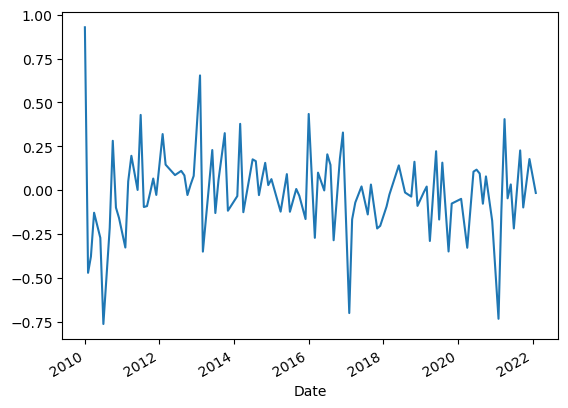

In [469]:
residuals.plot()

The residuals are showing a lot of white noise and variating around zero. This implies that the model is well specified and has successfully extracted the trend and autocorrelation structure from the data.

# AutoARIMA without predictors

In [470]:
y_train

,CPI
Date,
2010-01-01,5.9
2010-02-01,5.4
2010-03-01,4.9
2010-04-01,4.6
2010-06-01,4.3
...,...
2021-07-01,3.0
2021-09-01,3.2
2021-10-01,3.2


In [471]:
arima_model2 = auto_arima(y_train, m=12, trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=7.829, Time=0.94 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=4.502, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=4.571, Time=0.15 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=4.400, Time=0.15 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=3.466, Time=0.02 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=5.558, Time=0.08 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : AIC=5.892, Time=0.07 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=5.651, Time=0.18 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=3.117, Time=0.04 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=4.782, Time=0.12 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=4.214, Time=0.31 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=4.942, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : AIC=4.024, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=2.703, Time=0.08 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=4.211, Time=0.19 s

In [472]:
arima_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  102
Model:               SARIMAX(0, 1, 1)   Log Likelihood                   1.288
Date:                Fri, 12 Jun 2026   AIC                              1.424
Time:                        16:21:22   BIC                              6.654
Sample:                             0   HQIC                             3.541
                                - 102                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2168      0.111      1.947      0.052      -0.001       0.435
sigma2         0.0570      0.006      9.311      0.000       0.045       0.069
===================================================================================
Ljung-Box (L1) (Q):                   0.05   Jarque-Bera (JB):                12.55
Prob(Q):                              0.82   Prob(JB):                         0.00
Heteroskedasticity (H):               0.68   Skew:                            -0.54
Prob(H) (two-sided):                  0.26   Kurtosis:                         4.34
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [473]:
cpi_pred = arima_model2.predict(n_periods = len(y_test), X= x_test)

C:\Users\tebog\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\tebog\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [474]:
mean_absolute_error(y_test, cpi_pred)

0.8629138130208798

In [475]:
rmse = np.sqrt(mean_squared_error(y_test, cpi_pred))
print(rmse)

0.9833468102629979


In [476]:
#As seen above, cpi_pred is a Series
cpi_pred = pd.DataFrame(cpi_pred)

In [477]:
mape = np.mean(np.abs((y_test.values - cpi_pred.values) / test))*100
print(mape)

10.921350558984358


In [478]:
residuals = arima_model2.resid()

<Axes: xlabel='Date'>

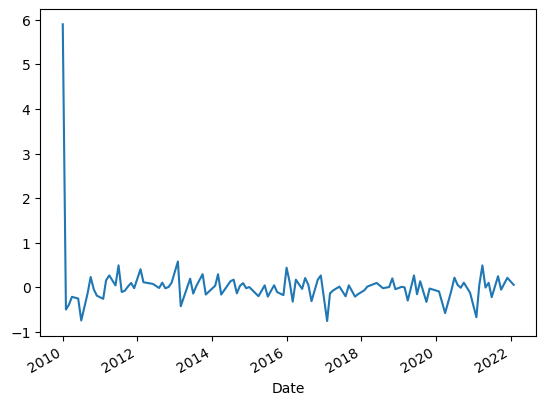

In [479]:
residuals.plot()

The residuals for this model are not showing any white noise, which means that the model has not captured trend and underlaying autocorrelation structure from the data.

# Summary and Conclusion
### Naive forecast
- MAE = 0.13
- RMSE = 0.17
- MAPE = 3%
### AutoArima with predictors
- MAE = 0.73
- RMSE = 0.86
- MAPE = 10.16%
### AutoArima without predictors
- MAE = 0.86
- RMSE = 0.98
- MAPE = 10.92%

Looking at the above summary, Naive forecast seems to be dramatically the better model of them all. Which as far as I'm concerned suggests that inflation(CPI) has a very strong persistence, such that, Last month's inflation is already an excellent predictor of this month's inflation.